In [1]:
import os

print("===== RESULT CSV FILES =====")

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

print("\n===== WORKING CSV FILES =====")

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

===== RESULT CSV FILES =====
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/catboost_predictions.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/catboost_results.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-correlation-55-models/xgb_55_predictions.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-correlation-55-models/55_feature_model_results_vertical.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-correlation-55-models/55_feature_model_results.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/correlation_55_features.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/boruta_results.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/shap_feature_ranking.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/selected_features.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-xgboost/xgb_predictions.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-xgboost/xgb_results.csv
/kaggle/input/notebooks/nadianoumee/id

# Final Compariosn

In [2]:
import pandas as pd

# =========================
# FILE PATHS
# =========================

# 77-feature baseline
rf_77_path = "/kaggle/input/notebooks/nadianoumee/ids-2017-random-forest/rf_results.csv"
lgbm_77_path = "/kaggle/input/notebooks/nadianoumee/ids-2017-lightgbm/lgbm_results.csv"
cat_77_path = "/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/catboost_results.csv"
xgb_77_path = "/kaggle/input/notebooks/nadianoumee/ids-2017-xgboost/xgb_results.csv"

# 55-feature
results_55_path = "/kaggle/input/notebooks/nadianoumee/ids-2017-correlation-55-models/55_feature_model_results.csv"

# 43-feature
results_43_path = "/kaggle/input/notebooks/nadianoumee/ids-2017-selected-features-43-models/selected_features_model_comparison.csv"


# =========================
# LOAD FILES
# =========================

rf_77 = pd.read_csv(rf_77_path)
lgbm_77 = pd.read_csv(lgbm_77_path)
cat_77 = pd.read_csv(cat_77_path)
xgb_77 = pd.read_csv(xgb_77_path)

results_55 = pd.read_csv(results_55_path)
results_43 = pd.read_csv(results_43_path)


# =========================
# CHECK
# =========================

print("===== 77 FEATURE RESULTS =====")

print("\nRandom Forest:")
print(rf_77)

print("\nLightGBM:")
print(lgbm_77)

print("\nCatBoost:")
print(cat_77)

print("\nXGBoost:")
print(xgb_77)


print("\n===== 55 FEATURE RESULTS =====")
print(results_55)


print("\n===== 43 FEATURE RESULTS =====")
print(results_43)

===== 77 FEATURE RESULTS =====

Random Forest:
           Model  Accuracy  Weighted Precision  Weighted Recall  Weighted F1  \
0  Random Forest  0.998412            0.998354         0.998412     0.998368   

   Macro Precision  Macro Recall  Macro F1       MCC       AUC  
0         0.926153      0.837711  0.863917  0.994101  0.999877  

LightGBM:
      Model  Accuracy  Weighted Precision  Weighted Recall  Weighted F1  \
0  LightGBM  0.953157            0.958594         0.953157     0.955516   

   Macro Precision  Macro Recall  Macro F1       MCC       AUC  
0         0.262833      0.275689  0.267333  0.826165  0.936349  

CatBoost:
      Model  Accuracy  Weighted Precision  Weighted Recall  Weighted F1  \
0  CatBoost  0.998022            0.998079         0.998022     0.997836   

   Macro Precision  Macro Recall  Macro F1       MCC       AUC  
0         0.906266      0.717303  0.746204  0.992644  0.999929  

XGBoost:
     Model  Accuracy  Weighted Precision  Weighted Recall  Weighted 

In [3]:
# ============================================
# FINAL 77 vs 55 vs 43 FEATURE COMPARISON
# ============================================

import pandas as pd

# ---------- 77 FEATURES ----------
baseline_77 = pd.concat(
    [rf_77, lgbm_77, cat_77, xgb_77],
    ignore_index=True
)

baseline_77["Features"] = 77


# ---------- 55 FEATURES ----------
results_55_clean = results_55.copy()
results_55_clean["Features"] = 55


# ---------- 43 FEATURES ----------
results_43_clean = results_43.copy()
results_43_clean["Features"] = 43


# ---------- COMBINE ----------
final_comparison = pd.concat(
    [
        baseline_77,
        results_55_clean,
        results_43_clean
    ],
    ignore_index=True
)


# Put Features first
cols = ["Features"] + [
    col for col in final_comparison.columns
    if col != "Features"
]

final_comparison = final_comparison[cols]


# Sort nicely
final_comparison = final_comparison.sort_values(
    by=["Features", "Model"]
).reset_index(drop=True)


# Round numerical values
numeric_cols = final_comparison.select_dtypes(
    include="number"
).columns

final_comparison[numeric_cols] = (
    final_comparison[numeric_cols].round(6)
)


# Display
print("===== FINAL 77 vs 55 vs 43 FEATURE COMPARISON =====")

display(final_comparison)

===== FINAL 77 vs 55 vs 43 FEATURE COMPARISON =====


,Features,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1,MCC,AUC
0,43,CatBoost,0.998071,0.998130,0.998071,0.997893,0.901801,0.725109,0.748347,0.992830,0.999934
1,43,LightGBM,0.849663,0.894872,0.849663,0.868465,0.166693,0.176575,0.167906,0.534280,0.823932
2,43,Random Forest,0.998510,0.998459,0.998510,0.998470,0.927352,0.832069,0.859371,0.994467,0.999865
3,43,XGBoost,0.998497,0.998482,0.998497,0.998359,0.955202,0.825275,0.850269,0.994414,0.999968
4,55,CatBoost,0.998035,0.998091,0.998035,0.997856,0.902742,0.723109,0.747840,0.992695,0.999933
5,55,LightGBM,0.910099,0.932960,0.910099,0.919583,0.180299,0.174027,0.175244,0.686007,0.896189
6,55,Random Forest,0.998488,0.998430,0.998488,0.998445,0.925712,0.831095,0.857991,0.994384,0.999874
7,55,XGBoost,0.998524,0.998472,0.998524,0.998381,0.945811,0.822900,0.848455,0.994514,0.999965
8,77,CatBoost,0.998022,0.998079,0.998022,0.997836,0.906266,0.717303,0.746204,0.992644,0.999929
9,77,LightGBM,0.953157,0.958594,0.953157,0.955516,0.262833,0.275689,0.267333,0.826165,0.936349


In [4]:
# Save CSV
final_comparison.to_csv(
    "/kaggle/working/final_77_55_43_model_comparison.csv",
    index=False
)

# Save Excel
final_comparison.to_excel(
    "/kaggle/working/final_77_55_43_model_comparison.xlsx",
    index=False
)

print("Final comparison saved successfully.")

Final comparison saved successfully.


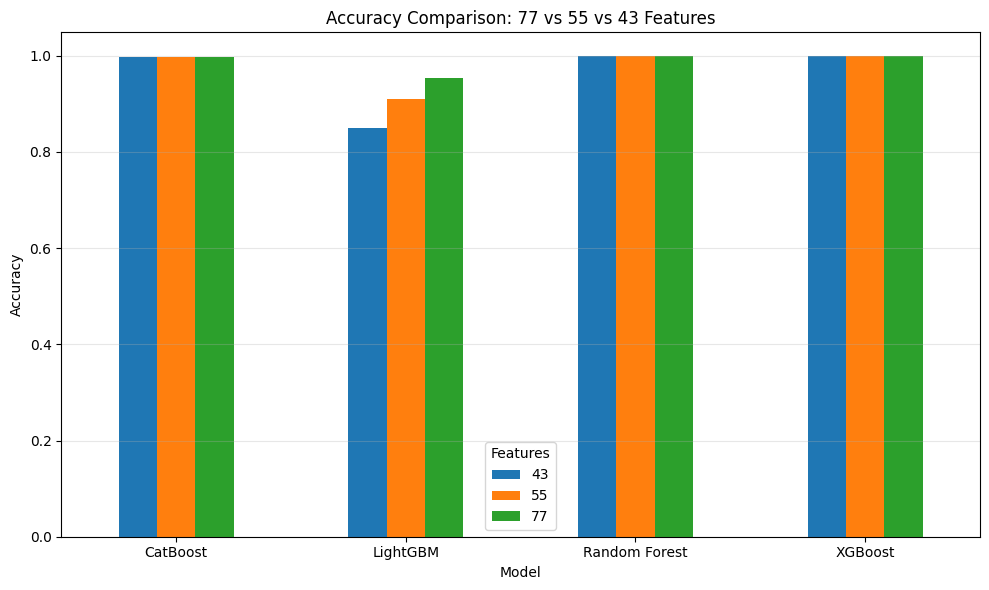

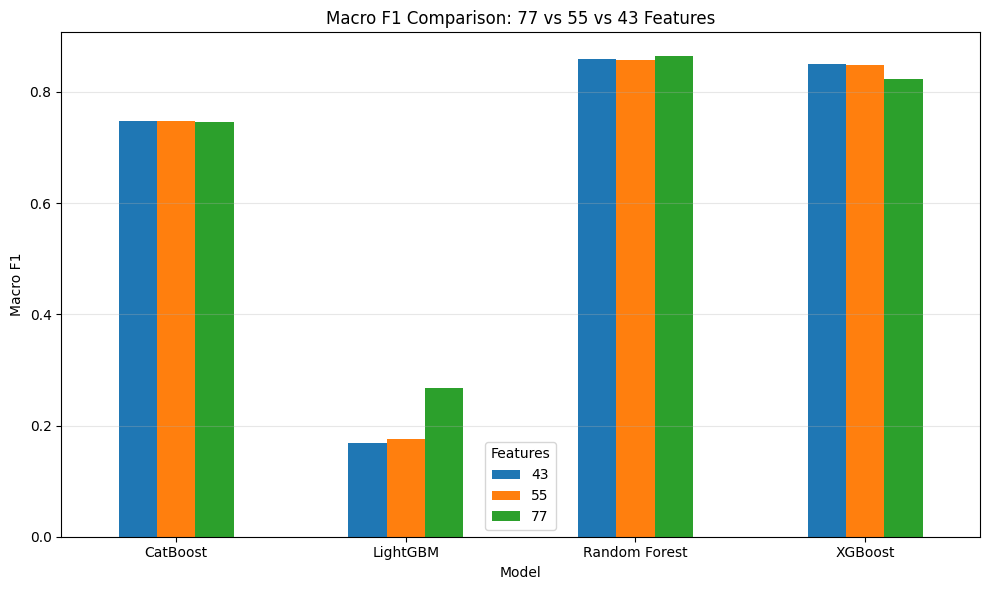

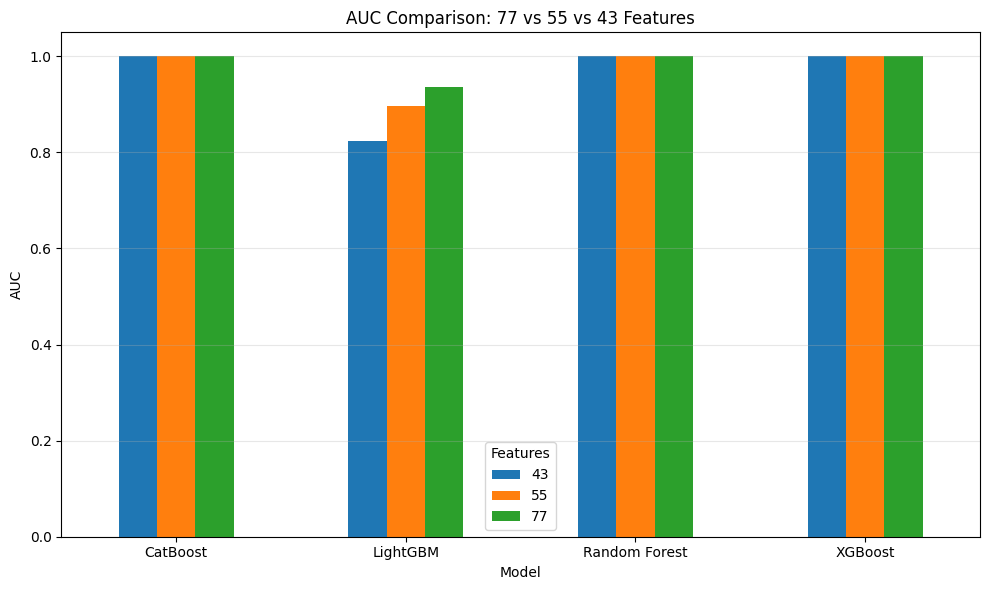


===== SAVED GRAPH FILES =====
/kaggle/working/accuracy_77_55_43.png
/kaggle/working/macro_f1_77_55_43.png
/kaggle/working/auc_77_55_43.png


In [5]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Macro F1",
    "AUC"
]

saved_files = []

for metric in metrics:

    plot_data = final_comparison.pivot(
        index="Model",
        columns="Features",
        values=metric
    )

    ax = plot_data.plot(
        kind="bar",
        figsize=(10, 6)
    )

    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} Comparison: 77 vs 55 vs 43 Features")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Features")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    filename = f"/kaggle/working/{metric.lower().replace(' ', '_')}_77_55_43.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    saved_files.append(filename)

    plt.show()
    plt.close()

print("\n===== SAVED GRAPH FILES =====")
for file in saved_files:
    print(file)

In [6]:
import pandas as pd
import os

base_path = "/kaggle/input/notebooks/nadianoumee/ids-2017-selected-features-43-models"

prediction_files = {
    "Random Forest": "rf_selected_predictions.csv",
    "LightGBM": "lgbm_selected_predictions.csv",
    "CatBoost": "catboost_selected_predictions.csv",
    "XGBoost": "xgb_selected_predictions.csv"
}

for model, file in prediction_files.items():
    
    path = os.path.join(base_path, file)
    
    df = pd.read_csv(path)
    
    print("\n" + "="*50)
    print(model)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    print("\nFirst 5 rows:")
    display(df.head())


Random Forest
Shape: (446345, 2)
Columns:
['Actual', 'Predicted']

First 5 rows:


,Actual,Predicted
0,0,0
1,0,0
2,4,4
3,0,0
4,0,0



LightGBM
Shape: (446345, 2)
Columns:
['Actual', 'Predicted']

First 5 rows:


,Actual,Predicted
0,0,0
1,0,2
2,4,4
3,0,0
4,0,0



CatBoost
Shape: (446345, 2)
Columns:
['Actual', 'Predicted']

First 5 rows:


,Actual,Predicted
0,0,0
1,0,0
2,4,4
3,0,0
4,0,0



XGBoost
Shape: (446345, 2)
Columns:
['Actual', 'Predicted']

First 5 rows:


,Actual,Predicted
0,0,0
1,0,0
2,4,4
3,0,0
4,0,0


In [7]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/catboost_model.pkl
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/__results__.html
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/catboost_predictions.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/__notebook__.ipynb
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/catboost_confusion_matrix.png
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/catboost_results.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/__output__.json
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/custom.css
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/__results___files/__results___6_0.png
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/catboost_info/learn_error.tsv
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/catboost_info/catboost_training.json
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/catboost_info/time_left.tsv
/kaggle/input/notebooks/nadianoumee/ids-2017-catboost/catboos

In [8]:
X_train = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/X_train_selected.parquet"
)

X_test = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/X_test_selected.parquet"
)

y_train = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/y_train_selected.parquet"
)["Label"]

y_test = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/y_test_selected.parquet"
)["Label"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nNumber of features:", X_train.shape[1])
print("Number of classes :", y_train.nunique())

X_train: (1785379, 43)
X_test : (446345, 43)
y_train: (1785379,)
y_test : (446345,)

Number of features: 43
Number of classes : 15


In [9]:
# ============================================
# Load 43-feature trained base models
# ============================================

import joblib

base_path = "/kaggle/input/notebooks/nadianoumee/ids-2017-selected-features-43-models"

rf_after = joblib.load(
    f"{base_path}/rf_selected_model.pkl"
)

lgbm_after = joblib.load(
    f"{base_path}/lgbm_selected_model.pkl"
)

cat_after = joblib.load(
    f"{base_path}/catboost_selected_model.pkl"
)

xgb_after = joblib.load(
    f"{base_path}/xgb_selected_model.pkl"
)

print("All 4 base models loaded successfully.")

print("Random Forest:", type(rf_after))
print("LightGBM:", type(lgbm_after))
print("CatBoost:", type(cat_after))
print("XGBoost:", type(xgb_after))

All 4 base models loaded successfully.
Random Forest: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
LightGBM: <class 'lightgbm.sklearn.LGBMClassifier'>
CatBoost: <class 'catboost.core.CatBoostClassifier'>
XGBoost: <class 'xgboost.sklearn.XGBClassifier'>


# 43-FEATURE STACKING ENSEMBLE

In [10]:
# ============================================
# Generate OOF predictions
# ============================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

# 3-fold stratified cross-validation
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

n_classes = y_train.nunique()

# Store OOF probabilities
oof_rf = np.zeros((len(y_train), n_classes), dtype=np.float32)
oof_lgbm = np.zeros((len(y_train), n_classes), dtype=np.float32)
oof_cat = np.zeros((len(y_train), n_classes), dtype=np.float32)
oof_xgb = np.zeros((len(y_train), n_classes), dtype=np.float32)

print("Generating OOF predictions...")
print("Training samples:", len(y_train))
print("Number of classes:", n_classes)

for fold, (train_idx, valid_idx) in enumerate(
    skf.split(X_train, y_train), 1
):
    
    print(f"\n========== Fold {fold}/3 ==========")

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[valid_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[valid_idx]

    # Clone the already-defined base models
    rf_model = clone(rf_after)
    lgbm_model = clone(lgbm_after)
    cat_model = clone(cat_after)
    xgb_model = clone(xgb_after)

    # Random Forest
    print("Random Forest...")
    rf_model.fit(X_tr, y_tr)
    oof_rf[valid_idx] = rf_model.predict_proba(X_val)

    # LightGBM
    print("LightGBM...")
    lgbm_model.fit(X_tr, y_tr)
    oof_lgbm[valid_idx] = lgbm_model.predict_proba(X_val)

    # CatBoost
    print("CatBoost...")
    cat_model.fit(X_tr, y_tr)
    oof_cat[valid_idx] = cat_model.predict_proba(X_val)

    # XGBoost
    print("XGBoost...")
    xgb_model.fit(X_tr, y_tr)
    oof_xgb[valid_idx] = xgb_model.predict_proba(X_val)

    print(f"Fold {fold} completed.")

print("\nOOF prediction generation completed.")

Generating OOF predictions...
Training samples: 1785379
Number of classes: 15

========== Fold 1/3 ==========
Random Forest...
LightGBM...
CatBoost...
XGBoost...
Fold 1 completed.

========== Fold 2/3 ==========
Random Forest...
LightGBM...
CatBoost...
XGBoost...
Fold 2 completed.

========== Fold 3/3 ==========
Random Forest...
LightGBM...
CatBoost...
XGBoost...
Fold 3 completed.

OOF prediction generation completed.


## STACKING META-MODEL
## Logistic Regression

In [11]:
# ============================================
# STACKING: CREATE META-FEATURES
# ============================================

import numpy as np

meta_features = np.column_stack([
    oof_rf,
    oof_lgbm,
    oof_cat,
    oof_xgb
])

print("Meta-feature shape:", meta_features.shape)
print("Expected shape:", (len(y_train), 60))

Meta-feature shape: (1785379, 60)
Expected shape: (1785379, 60)


In [12]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

print("Training Logistic Regression meta-model...")

meta_model.fit(
    meta_features,
    y_train
)

print("Logistic Regression meta-model training completed.")

Training Logistic Regression meta-model...
Logistic Regression meta-model training completed.


In [13]:

print("Generating test predictions from base models...")

test_rf = rf_after.predict_proba(X_test)
test_lgbm = lgbm_after.predict_proba(X_test)
test_cat = cat_after.predict_proba(X_test)
test_xgb = xgb_after.predict_proba(X_test)

# Combine the 4 models
meta_test = np.column_stack([
    test_rf,
    test_lgbm,
    test_cat,
    test_xgb
])

print("Meta-test shape:", meta_test.shape)
print("Expected shape:", (len(y_test), 60))

# Final stacking predictions
y_pred_stack = meta_model.predict(meta_test)
y_prob_stack = meta_model.predict_proba(meta_test)

print("Stacking test prediction completed.")
print("Prediction shape:", y_pred_stack.shape)
print("Probability shape:", y_prob_stack.shape)

Generating test predictions from base models...
Meta-test shape: (446345, 60)
Expected shape: (446345, 60)
Stacking test prediction completed.
Prediction shape: (446345,)
Probability shape: (446345, 15)


In [14]:
# ============================================
# STACKING ENSEMBLE - FINAL EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

stack_accuracy = accuracy_score(
    y_test,
    y_pred_stack
)

stack_precision_weighted = precision_score(
    y_test,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

stack_recall_weighted = recall_score(
    y_test,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

stack_f1_weighted = f1_score(
    y_test,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

stack_precision_macro = precision_score(
    y_test,
    y_pred_stack,
    average="macro",
    zero_division=0
)

stack_recall_macro = recall_score(
    y_test,
    y_pred_stack,
    average="macro",
    zero_division=0
)

stack_f1_macro = f1_score(
    y_test,
    y_pred_stack,
    average="macro",
    zero_division=0
)

stack_mcc = matthews_corrcoef(
    y_test,
    y_pred_stack
)

stack_auc = roc_auc_score(
    y_test,
    y_prob_stack,
    multi_class="ovr",
    average="weighted"
)

print("===== STACKING ENSEMBLE RESULTS =====")
print(f"Accuracy          : {stack_accuracy:.6f}")
print(f"Weighted Precision: {stack_precision_weighted:.6f}")
print(f"Weighted Recall   : {stack_recall_weighted:.6f}")
print(f"Weighted F1       : {stack_f1_weighted:.6f}")
print(f"Macro Precision   : {stack_precision_macro:.6f}")
print(f"Macro Recall      : {stack_recall_macro:.6f}")
print(f"Macro F1          : {stack_f1_macro:.6f}")
print(f"MCC               : {stack_mcc:.6f}")
print(f"AUC               : {stack_auc:.6f}")

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        y_pred_stack,
        zero_division=0
    )
)

===== STACKING ENSEMBLE RESULTS =====
Accuracy          : 0.998546
Weighted Precision: 0.998463
Weighted Recall   : 0.998546
Weighted F1       : 0.998402
Macro Precision   : 0.741260
Macro Recall      : 0.694824
Macro F1          : 0.697714
MCC               : 0.994599
AUC               : 0.999953

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    379047
           1       0.87      0.62      0.73       288
           2       1.00      1.00      1.00     25603
           3       1.00      0.99      1.00      2057
           4       1.00      1.00      1.00     34569
           5       0.95      0.98      0.97      1046
           6       0.99      0.99      0.99      1077
           7       1.00      0.99      1.00      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.94      0.91      0.92       391
          11     

In [15]:
# ==========================================
# SAVE STACKING META-MODEL
# ==========================================

import joblib
import os

os.makedirs("/kaggle/working/final_outputs", exist_ok=True)

joblib.dump(
    meta_model,
    "/kaggle/working/final_outputs/stacking_meta_model.pkl"
)

print("Stacking meta-model saved successfully.")

Stacking meta-model saved successfully.


In [16]:
import os
import numpy as np
import pandas as pd

output_dir = "/kaggle/working/final_outputs"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Final 77 vs 55 vs 43 comparison
# ------------------------------------------------------------

final_comparison.to_csv(
    f"{output_dir}/final_77_55_43_model_comparison.csv",
    index=False
)

final_comparison.to_excel(
    f"{output_dir}/final_77_55_43_model_comparison.xlsx",
    index=False
)


# ------------------------------------------------------------
# 2. Stacking evaluation results
# ------------------------------------------------------------

stack_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "MCC",
        "AUC"
    ],
    "Value": [
        stack_accuracy,
        stack_precision_weighted,
        stack_recall_weighted,
        stack_f1_weighted,
        stack_precision_macro,
        stack_recall_macro,
        stack_f1_macro,
        stack_mcc,
        stack_auc
    ]
})

stack_results.to_csv(
    f"{output_dir}/stacking_results.csv",
    index=False
)

stack_results.to_excel(
    f"{output_dir}/stacking_results.xlsx",
    index=False
)


# ------------------------------------------------------------
# 3. Stacking predictions
# ------------------------------------------------------------

stack_predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_stack
})

stack_predictions.to_csv(
    f"{output_dir}/stacking_predictions.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Stacking probabilities
# ------------------------------------------------------------

stack_probabilities = pd.DataFrame(
    y_prob_stack,
    columns=[
        f"Class_{i}"
        for i in range(y_prob_stack.shape[1])
    ]
)

stack_probabilities.to_csv(
    f"{output_dir}/stacking_probabilities.csv",
    index=False
)


# ------------------------------------------------------------
# 5. OOF predictions
# ------------------------------------------------------------

np.save(f"{output_dir}/oof_rf.npy", oof_rf)
np.save(f"{output_dir}/oof_lgbm.npy", oof_lgbm)
np.save(f"{output_dir}/oof_cat.npy", oof_cat)
np.save(f"{output_dir}/oof_xgb.npy", oof_xgb)

np.save(f"{output_dir}/meta_features.npy", meta_features)


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("========================================")
print("ALL REMAINING OUTPUTS SAVED")
print("========================================")
print(f"\nLocation: {output_dir}\n")

for file in sorted(os.listdir(output_dir)):
    print("✓", file)

ALL REMAINING OUTPUTS SAVED

Location: /kaggle/working/final_outputs

✓ final_77_55_43_model_comparison.csv
✓ final_77_55_43_model_comparison.xlsx
✓ meta_features.npy
✓ oof_cat.npy
✓ oof_lgbm.npy
✓ oof_rf.npy
✓ oof_xgb.npy
✓ stacking_meta_model.pkl
✓ stacking_predictions.csv
✓ stacking_probabilities.csv
✓ stacking_results.csv
✓ stacking_results.xlsx


# SHAP EXPLAINABILITY

In [17]:
import shap
import numpy as np

# Use a small representative sample
sample_size = 1000

X_shap = X_test.sample(
    n=sample_size,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (1000, 43)


In [18]:
# ============================================
# FINAL STACKING MODEL FUNCTION FOR SHAP
# ============================================

def stacking_predict_proba(X):
    
    # Base model probabilities
    rf_prob = rf_after.predict_proba(X)
    lgbm_prob = lgbm_after.predict_proba(X)
    cat_prob = cat_after.predict_proba(X)
    xgb_prob = xgb_after.predict_proba(X)
    
    # Create stacking meta-features
    meta_X = np.column_stack([
        rf_prob,
        lgbm_prob,
        cat_prob,
        xgb_prob
    ])
    
    # Final Logistic Regression meta-model
    return meta_model.predict_proba(meta_X)


print("Stacking prediction function created.")

Stacking prediction function created.


In [19]:
# ============================================
# SHAP BACKGROUND DATA
# ============================================

background_size = 100

X_background = X_test.sample(
    n=background_size,
    random_state=42
)

print("SHAP background shape:", X_background.shape)

SHAP background shape: (100, 43)


In [20]:
# ============================================
# CREATE SHAP EXPLAINER
# ============================================

print("Creating SHAP explainer...")

explainer = shap.Explainer(
    stacking_predict_proba,
    X_background,
    algorithm="permutation"
)

print("SHAP explainer created successfully.")

Creating SHAP explainer...
SHAP explainer created successfully.


In [21]:
# ============================================
# CALCULATE SHAP VALUES
# ============================================

X_shap_small = X_shap.iloc[:200].copy()

print("Calculating SHAP values...")
print("Samples:", X_shap_small.shape[0])
print("Features:", X_shap_small.shape[1])

shap_values = explainer(
    X_shap_small,
    max_evals=2000
)

print("SHAP calculation completed.")
print("SHAP values shape:", shap_values.values.shape)

Calculating SHAP values...
Samples: 200
Features: 43


PermutationExplainer explainer: 201it [46:21, 13.91s/it]

SHAP calculation completed.
SHAP values shape: (200, 43, 15)


/tmp/ipykernel_16/1929613808.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


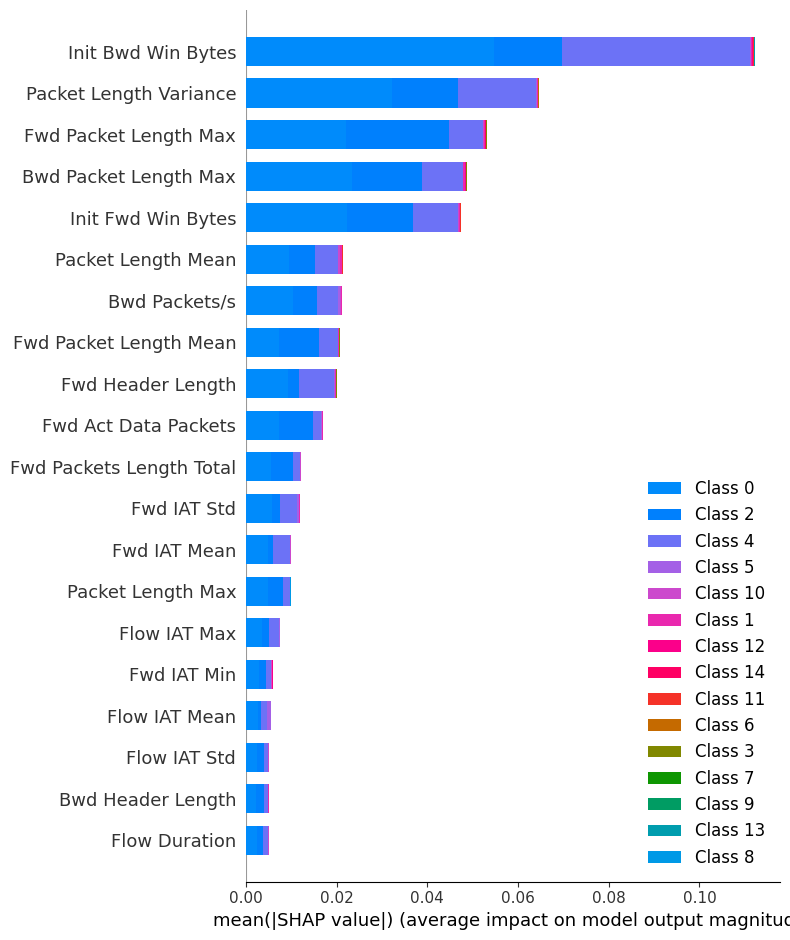

In [22]:
# ============================================
# SHAP SUMMARY PLOT
# ============================================

shap.summary_plot(
    shap_values,
    X_shap_small,
    show=True
)

/tmp/ipykernel_16/2167923217.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


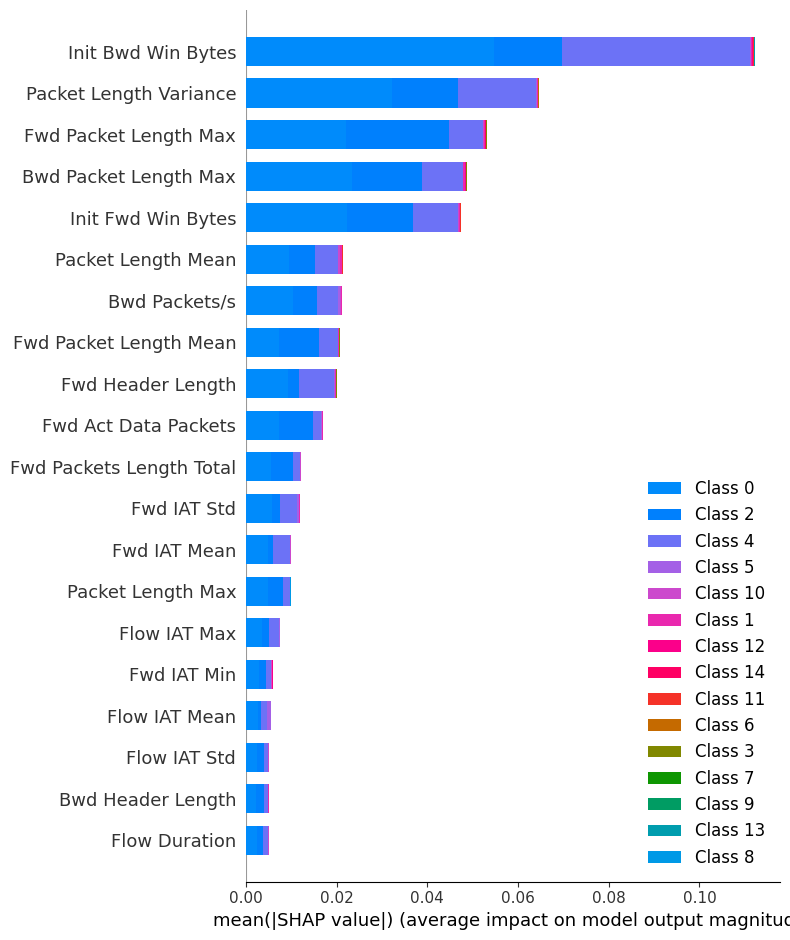

In [23]:
# ============================================
# SHAP FEATURE IMPORTANCE
# ============================================

shap.summary_plot(
    shap_values,
    X_shap_small,
    plot_type="bar",
    show=True
)

In [24]:
# ============================================
# SAVE SHAP OUTPUTS
# ============================================

shap_dir = "/kaggle/working/final_outputs/shap"
os.makedirs(shap_dir, exist_ok=True)

# Save SHAP values
np.save(
    f"{shap_dir}/stacking_shap_values.npy",
    shap_values.values
)

# Save the SHAP sample
X_shap_small.to_csv(
    f"{shap_dir}/shap_sample.csv",
    index=False
)

print("SHAP values saved.")
print("SHAP sample saved.")

SHAP values saved.
SHAP sample saved.


In [25]:
# ============================================
# SAVE SHAP SUMMARY + BAR PLOTS
# ============================================

# Summary plot
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap_small,
    show=False
)

plt.tight_layout()

plt.savefig(
    f"{shap_dir}/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Bar plot
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap_small,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    f"{shap_dir}/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("SHAP graphs saved successfully.") 

/tmp/ipykernel_16/1643811308.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_16/1643811308.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


SHAP graphs saved successfully.


# LIME EXPLAINABILITY

In [26]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd
import os

print("LIME setup started...")


# Final stacking prediction function
def stacking_predict(X):

    # Base model probabilities
    rf_prob = rf_after.predict_proba(X)
    lgbm_prob = lgbm_after.predict_proba(X)
    cat_prob = cat_after.predict_proba(X)
    xgb_prob = xgb_after.predict_proba(X)

    # 60 meta-features
    meta_X = np.column_stack([
        rf_prob,
        lgbm_prob,
        cat_prob,
        xgb_prob
    ])

    # Logistic Regression meta-learner
    return meta_model.predict_proba(meta_X)


print("Stacking prediction function ready.")

LIME setup started...
Stacking prediction function ready.


In [27]:
# ============================================
# CREATE LIME EXPLAINER
# ============================================

lime_background_size = 5000

X_lime_background = X_train.sample(
    n=lime_background_size,
    random_state=42
)

# Class names
class_names = [
    str(c) for c in sorted(y_train.unique())
]

lime_explainer = LimeTabularExplainer(
    X_lime_background.values,
    feature_names=X_train.columns.tolist(),
    class_names=class_names,
    mode="classification",
    random_state=42
)

print("LIME explainer created successfully.")
print("Background shape:", X_lime_background.shape)
print("Number of classes:", len(class_names))

LIME explainer created successfully.
Background shape: (5000, 43)
Number of classes: 15


In [28]:
# ============================================
# SELECT ONE SAMPLE FOR LIME
# ============================================

lime_index = 0

X_lime_instance = X_test.iloc[lime_index]

actual_class = y_test.iloc[lime_index]

predicted_prob = stacking_predict(
    X_lime_instance.to_numpy().reshape(1, -1)
)[0]

predicted_class = np.argmax(predicted_prob)

print("Actual class   :", actual_class)
print("Predicted class:", predicted_class)
print("Prediction probability:", predicted_prob[predicted_class])

Actual class   : 0
Predicted class: 0
Prediction probability: 0.999654803876181


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [29]:
# ============================================
# GENERATE LIME EXPLANATION
# ============================================

lime_exp = lime_explainer.explain_instance(
    X_lime_instance.values,
    stacking_predict,
    num_features=15,
    top_labels=3
)

print("LIME explanation generated successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LIME explanation generated successfully.


In [30]:
# ============================================
# DISPLAY LIME EXPLANATION
# ============================================

lime_exp.show_in_notebook(show_table=True)

In [31]:
# ============================================
# SAVE LIME EXPLANATION
# ============================================

lime_dir = "/kaggle/working/final_outputs/lime"

os.makedirs(lime_dir, exist_ok=True)

lime_exp.save_to_file(
    f"{lime_dir}/lime_explanation.html"
)

print("LIME explanation saved successfully.")

LIME explanation saved successfully.


In [32]:
# ============================================
# SAVE LIME FEATURE CONTRIBUTIONS
# ============================================

lime_list = lime_exp.as_list(
    label=predicted_class
)

lime_df = pd.DataFrame(
    lime_list,
    columns=["Feature", "Contribution"]
)

lime_df.to_csv(
    f"{lime_dir}/lime_feature_contributions.csv",
    index=False
)

print("LIME feature contributions saved.")
print(lime_df)

LIME feature contributions saved.
                               Feature  Contribution
0      Bwd Packet Length Max > 1413.00     -0.010184
1          Fwd Act Data Packets > 3.00     -0.009574
2   Packet Length Variance > 178517.74     -0.003625
3          Packet Length Mean > 192.42      0.002887
4                Fwd PSH Flags <= 0.00     -0.002304
5           Fwd Header Length > 172.00     -0.002238
6      4.00 < Bwd IAT Max <= 177120.00      0.002004
7    20.00 < Fwd Seg Size Min <= 32.00     -0.001818
8                   Active Min <= 0.00      0.001629
9                Bwd Packets/s > 74.73      0.001602
10    26.61 < Flow IAT Std <= 18445.48     -0.001551
11          1.00 < Fwd IAT Min <= 3.00      0.001543
12          Bwd Header Length > 144.00     -0.001528
13   Fwd Packets Length Total > 364.00      0.001507
14         Packet Length Max > 1430.00     -0.001443


# FINAL EVALUATION & COMPARISON

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

final_dir = "/kaggle/working/final_outputs/final_evaluation"
os.makedirs(final_dir, exist_ok=True)

print("Final evaluation folder ready.")

Final evaluation folder ready.


In [34]:
# ============================================
# FINAL STACKING METRICS
# ============================================

stack_accuracy = accuracy_score(
    y_test,
    y_pred_stack
)

stack_precision = precision_score(
    y_test,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

stack_recall = recall_score(
    y_test,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

stack_f1 = f1_score(
    y_test,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

stack_macro_precision = precision_score(
    y_test,
    y_pred_stack,
    average="macro",
    zero_division=0
)

stack_macro_recall = recall_score(
    y_test,
    y_pred_stack,
    average="macro",
    zero_division=0
)

stack_macro_f1 = f1_score(
    y_test,
    y_pred_stack,
    average="macro",
    zero_division=0
)

stack_mcc = matthews_corrcoef(
    y_test,
    y_pred_stack
)

# Multiclass AUC
stack_auc = 0

try:
    from sklearn.preprocessing import label_binarize

    y_test_bin = label_binarize(
        y_test,
        classes=np.arange(y_prob_stack.shape[1])
    )

    from sklearn.metrics import roc_auc_score

    stack_auc = roc_auc_score(
        y_test_bin,
        y_prob_stack,
        multi_class="ovr",
        average="weighted"
    )

except Exception as e:
    print("AUC calculation warning:", e)

print("===== STACKING FINAL RESULTS =====")
print(f"Accuracy          : {stack_accuracy:.6f}")
print(f"Weighted Precision: {stack_precision:.6f}")
print(f"Weighted Recall   : {stack_recall:.6f}")
print(f"Weighted F1       : {stack_f1:.6f}")
print(f"Macro Precision   : {stack_macro_precision:.6f}")
print(f"Macro Recall      : {stack_macro_recall:.6f}")
print(f"Macro F1          : {stack_macro_f1:.6f}")
print(f"MCC               : {stack_mcc:.6f}")
print(f"AUC               : {stack_auc:.6f}")

===== STACKING FINAL RESULTS =====
Accuracy          : 0.998546
Weighted Precision: 0.998463
Weighted Recall   : 0.998546
Weighted F1       : 0.998402
Macro Precision   : 0.741260
Macro Recall      : 0.694824
Macro F1          : 0.697714
MCC               : 0.994599
AUC               : 0.999953


In [35]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

print("===== FINAL STACKING CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred_stack,
        zero_division=0
    )
)

# Save report
report_dict = classification_report(
    y_test,
    y_pred_stack,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(
    f"{final_dir}/stacking_classification_report.csv"
)

print("Classification report saved.")

===== FINAL STACKING CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    379047
           1       0.87      0.62      0.73       288
           2       1.00      1.00      1.00     25603
           3       1.00      0.99      1.00      2057
           4       1.00      1.00      1.00     34569
           5       0.95      0.98      0.97      1046
           6       0.99      0.99      0.99      1077
           7       1.00      0.99      1.00      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.94      0.91      0.92       391
          11       1.00      0.98      0.99       644
          12       0.70      0.90      0.79       294
          13       0.00      0.00      0.00         4
          14       0.67      0.05      0.09       130

    accuracy                           1.00    446345
   macro avg       0.74      0.

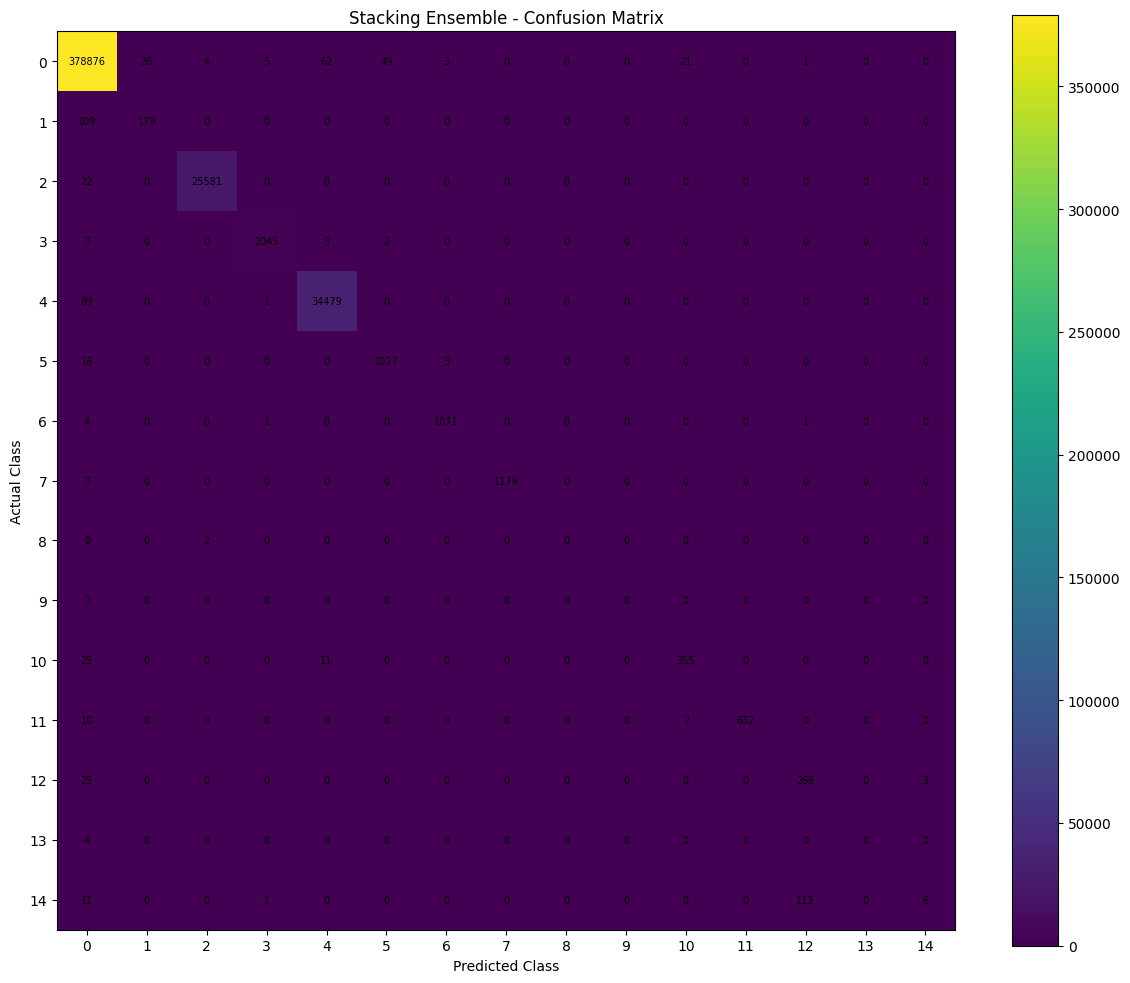

Raw confusion matrix saved.


In [36]:
# ============================================
# RAW CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred_stack
)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.title("Stacking Ensemble - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.colorbar()

classes = np.arange(len(np.unique(y_test)))

plt.xticks(classes)
plt.yticks(classes)

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()

plt.savefig(
    f"{final_dir}/stacking_confusion_matrix_raw.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("Raw confusion matrix saved.")

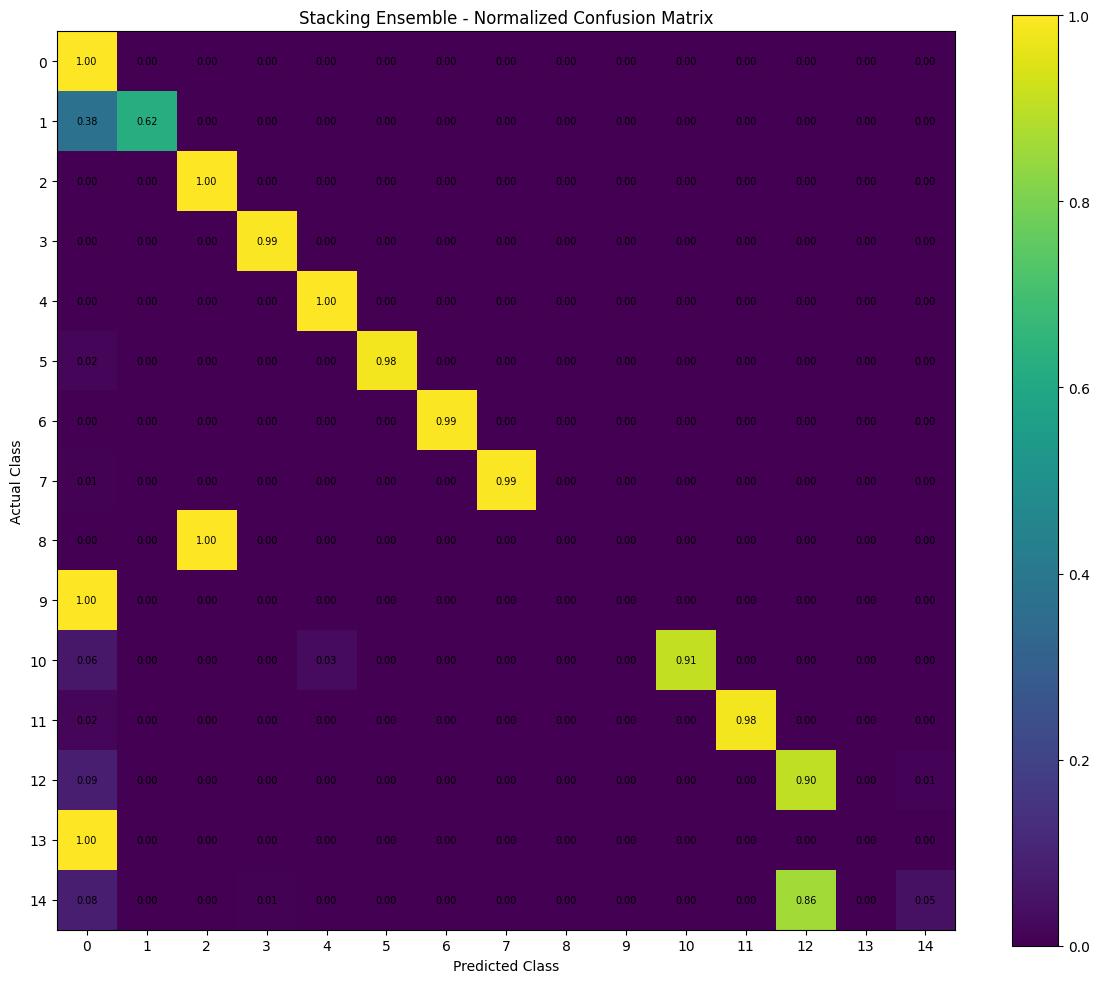

Normalized confusion matrix saved.


In [37]:
# ============================================
# NORMALIZED CONFUSION MATRIX
# ============================================

cm_normalized = confusion_matrix(
    y_test,
    y_pred_stack,
    normalize="true"
)

plt.figure(figsize=(12, 10))

plt.imshow(cm_normalized)

plt.title("Stacking Ensemble - Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.colorbar()

classes = np.arange(len(np.unique(y_test)))

plt.xticks(classes)
plt.yticks(classes)

for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()

plt.savefig(
    f"{final_dir}/stacking_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("Normalized confusion matrix saved.")

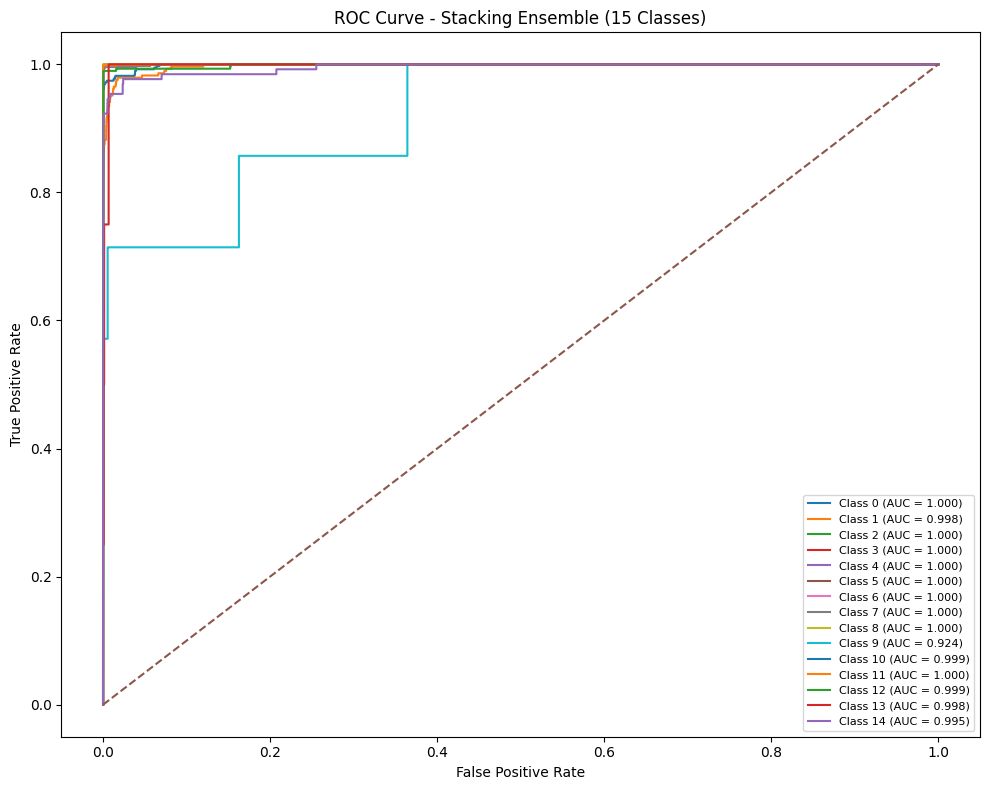

15-class ROC curve saved.


In [38]:
# ============================================
# MULTICLASS ROC CURVE - 15 CLASSES
# ============================================

from sklearn.preprocessing import label_binarize

classes = np.arange(y_prob_stack.shape[1])

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

plt.figure(figsize=(10, 8))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_stack[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"Class {i} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Stacking Ensemble (15 Classes)"
)

plt.legend(
    loc="lower right",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    f"{final_dir}/stacking_roc_15_classes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("15-class ROC curve saved.")

In [39]:
# ============================================
# BASE MODELS + STACKING COMPARISON
# ============================================

stacking_row = pd.DataFrame({
    "Features": [43],
    "Model": ["Stacking Ensemble"],
    "Accuracy": [stack_accuracy],
    "Weighted Precision": [stack_precision],
    "Weighted Recall": [stack_recall],
    "Weighted F1": [stack_f1],
    "Macro Precision": [stack_macro_precision],
    "Macro Recall": [stack_macro_recall],
    "Macro F1": [stack_macro_f1],
    "MCC": [stack_mcc],
    "AUC": [stack_auc]
})

# Add stacking to the existing 77/55/43 comparison
final_model_comparison = pd.concat(
    [
        final_comparison,
        stacking_row
    ],
    ignore_index=True
)

print("===== FINAL MODEL COMPARISON =====")

display(final_model_comparison)

===== FINAL MODEL COMPARISON =====


,Features,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1,MCC,AUC
0,43,CatBoost,0.998071,0.998130,0.998071,0.997893,0.901801,0.725109,0.748347,0.992830,0.999934
1,43,LightGBM,0.849663,0.894872,0.849663,0.868465,0.166693,0.176575,0.167906,0.534280,0.823932
2,43,Random Forest,0.998510,0.998459,0.998510,0.998470,0.927352,0.832069,0.859371,0.994467,0.999865
3,43,XGBoost,0.998497,0.998482,0.998497,0.998359,0.955202,0.825275,0.850269,0.994414,0.999968
4,55,CatBoost,0.998035,0.998091,0.998035,0.997856,0.902742,0.723109,0.747840,0.992695,0.999933
5,55,LightGBM,0.910099,0.932960,0.910099,0.919583,0.180299,0.174027,0.175244,0.686007,0.896189
6,55,Random Forest,0.998488,0.998430,0.998488,0.998445,0.925712,0.831095,0.857991,0.994384,0.999874
7,55,XGBoost,0.998524,0.998472,0.998524,0.998381,0.945811,0.822900,0.848455,0.994514,0.999965
8,77,CatBoost,0.998022,0.998079,0.998022,0.997836,0.906266,0.717303,0.746204,0.992644,0.999929
9,77,LightGBM,0.953157,0.958594,0.953157,0.955516,0.262833,0.275689,0.267333,0.826165,0.936349


In [40]:
# ============================================
# SAVE FINAL MODEL COMPARISON
# ============================================

final_model_comparison.to_csv(
    "/kaggle/working/final_outputs/final_model_comparison_with_stacking.csv",
    index=False
)

final_model_comparison.to_excel(
    "/kaggle/working/final_outputs/final_model_comparison_with_stacking.xlsx",
    index=False
)

print("Final model comparison saved successfully.")
print("CSV and Excel files created.")

Final model comparison saved successfully.
CSV and Excel files created.


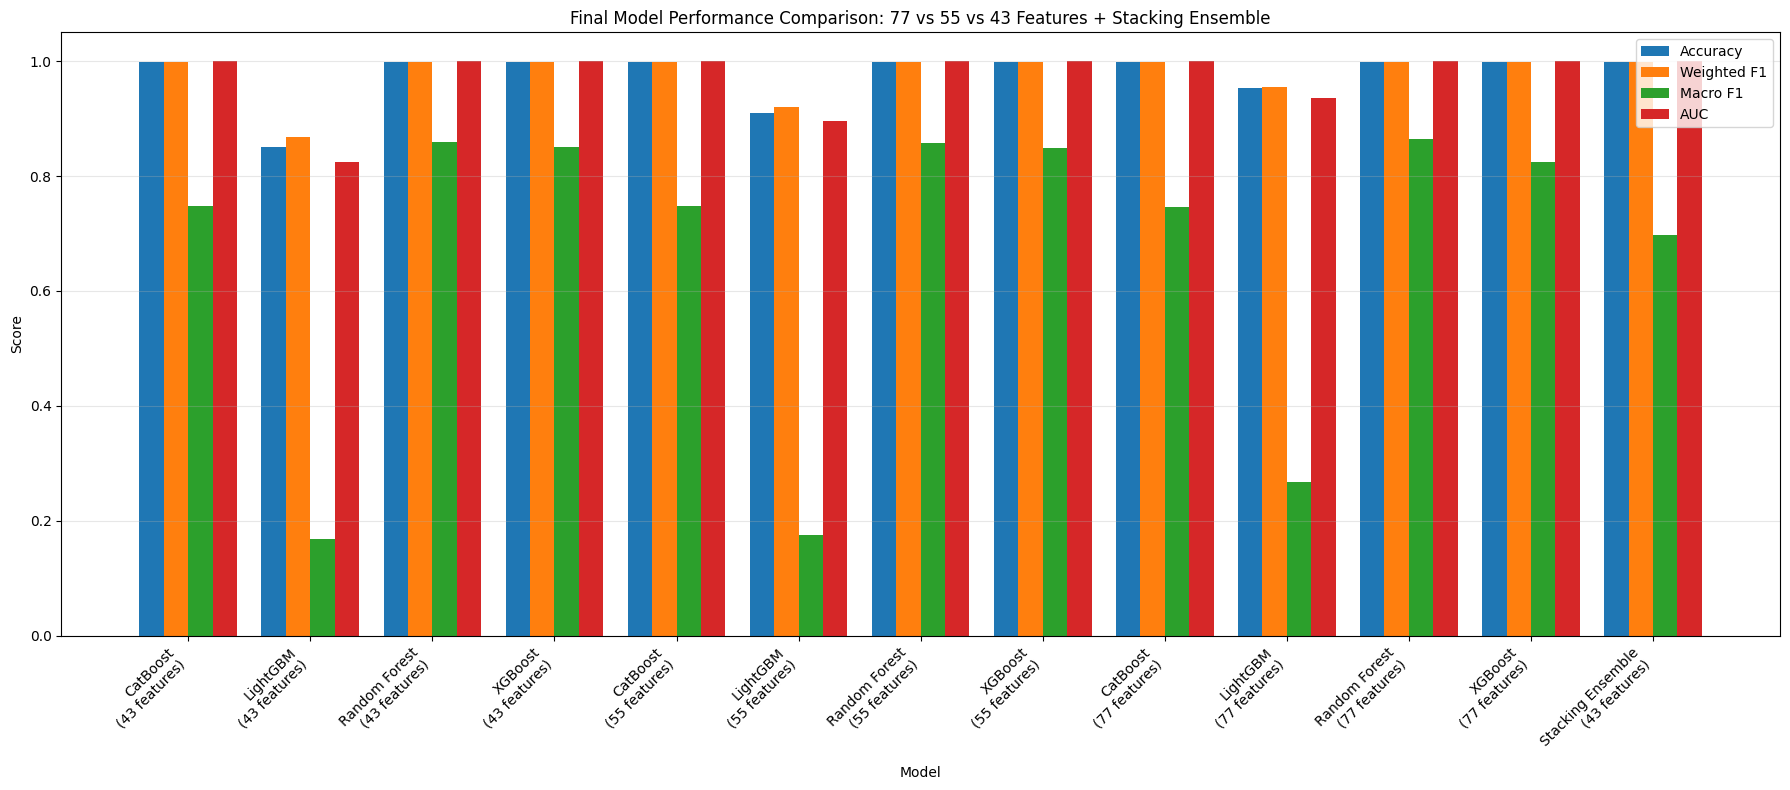

Final comparison bar chart saved successfully.


In [41]:
# ============================================
# FINAL MODEL COMPARISON BAR CHART
# 77 vs 55 vs 43 + Stacking
# ============================================

import matplotlib.pyplot as plt
import numpy as np

plot_df = final_model_comparison.copy()

# Create readable label
plot_df["Label"] = (
    plot_df["Model"].astype(str)
    + "\n("
    + plot_df["Features"].astype(str)
    + " features)"
)

metrics = [
    "Accuracy",
    "Weighted F1",
    "Macro F1",
    "AUC"
]

x = np.arange(len(plot_df))
width = 0.20

plt.figure(figsize=(18, 8))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        plot_df[metric],
        width,
        label=metric
    )

plt.xticks(
    x,
    plot_df["Label"],
    rotation=45,
    ha="right"
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.title(
    "Final Model Performance Comparison: "
    "77 vs 55 vs 43 Features + Stacking Ensemble"
)

plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save graph
plt.savefig(
    "/kaggle/working/final_outputs/"
    "final_model_comparison_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final comparison bar chart saved successfully.")

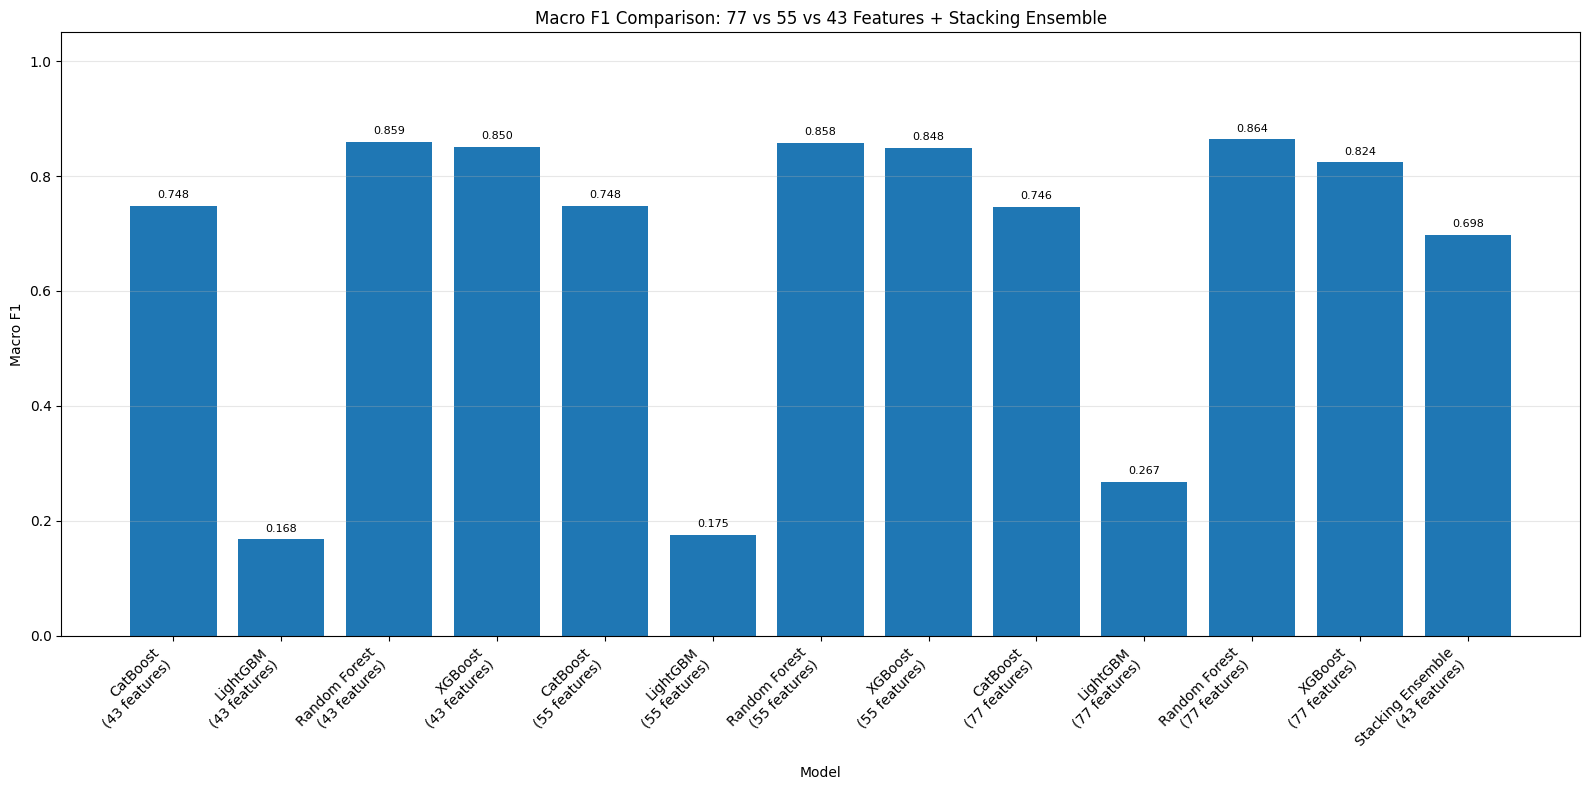

Macro F1 comparison graph saved successfully.


In [42]:
# ============================================
# MACRO F1 COMPARISON
# 77 vs 55 vs 43 + STACKING
# ============================================

import matplotlib.pyplot as plt

macro_f1_df = final_model_comparison.copy()

# Create readable labels
macro_f1_df["Label"] = (
    macro_f1_df["Model"].astype(str)
    + "\n("
    + macro_f1_df["Features"].astype(str)
    + " features)"
)

plt.figure(figsize=(16, 8))

bars = plt.bar(
    macro_f1_df["Label"],
    macro_f1_df["Macro F1"]
)

# Add exact values on top of bars
for bar, value in zip(bars, macro_f1_df["Macro F1"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.ylabel("Macro F1")
plt.xlabel("Model")
plt.title(
    "Macro F1 Comparison: 77 vs 55 vs 43 Features + Stacking Ensemble"
)

plt.ylim(0, 1.05)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

# Save
plt.savefig(
    "/kaggle/working/final_outputs/"
    "macro_f1_comparison_77_55_43_stacking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Macro F1 comparison graph saved successfully.")